import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

import warnings
warnings.filterwarnings("ignore")

GRAPH_PATH = r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\Students Success Predictor Model\Graphs"

In [2]:
df = pd.read_csv(r"C:\Users\shobh\OneDrive\Attachments\Documents\Desktop\py\student_performance_analysis.csv")

df.head()

,student_id,gender,hours_studied,attendance_percent,assignments_completed,test_score
0,1,Female,6.3,61,6,50.9
1,2,Male,7.6,62,7,51.8
2,3,Female,8.9,63,8,52.7
3,4,Male,10.2,64,9,53.6
4,5,Female,11.5,65,10,54.5


In [3]:
# lets understand the dataset 

print("Shape :", df.shape)

print("\nColumns:")

print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape : (50, 6)

Columns:
Index(['student_id', 'gender', 'hours_studied', 'attendance_percent',
       'assignments_completed', 'test_score'],
      dtype='object')

Data Types:
student_id                 int64
gender                    object
hours_studied            float64
attendance_percent         int64
assignments_completed      int64
test_score               float64
dtype: object


In [4]:
df.isnull().sum()

#missing values

student_id               0
gender                   0
hours_studied            0
attendance_percent       0
assignments_completed    0
test_score               0
dtype: int64

In [5]:
#duplicated values 

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [6]:
# describe stats

print(df.describe())

df.info()

       student_id  hours_studied  attendance_percent  assignments_completed  \
count    50.00000      50.000000           50.000000              50.000000   
mean     25.50000      10.850000           76.700000               9.500000   
std      14.57738       3.771875           11.935627               2.901442   
min       1.00000       5.000000           60.000000               5.000000   
25%      13.25000       7.600000           66.250000               7.000000   
50%      25.50000      10.850000           74.500000               9.500000   
75%      37.75000      14.100000           86.750000              12.000000   
max      50.00000      16.700000           99.000000              14.000000   

       test_score  
count   50.000000  
mean    72.050000  
std     13.119642  
min     50.000000  
25%     61.025000  
50%     72.050000  
75%     83.075000  
max     94.100000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   C

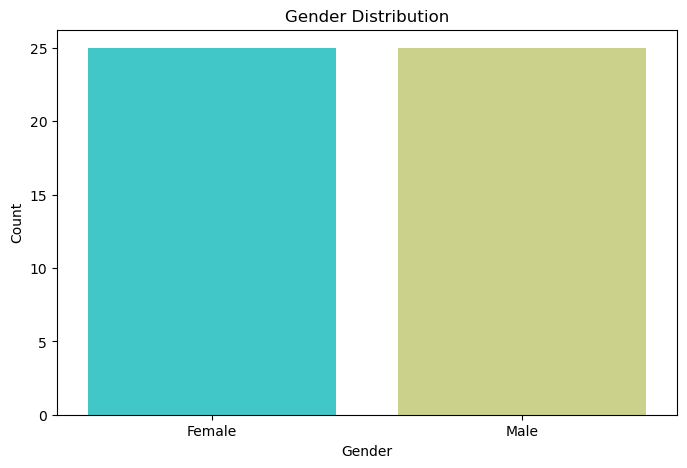

In [7]:
# Gender Diistribution Graphs

plt.figure(figsize=(8,5))

sns.countplot(data=df,x="gender",palette = 'rainbow')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")


plt.savefig(f"{GRAPH_PATH}\\gender_distribution.png",dpi=300,bbox_inches="tight")

plt.show()

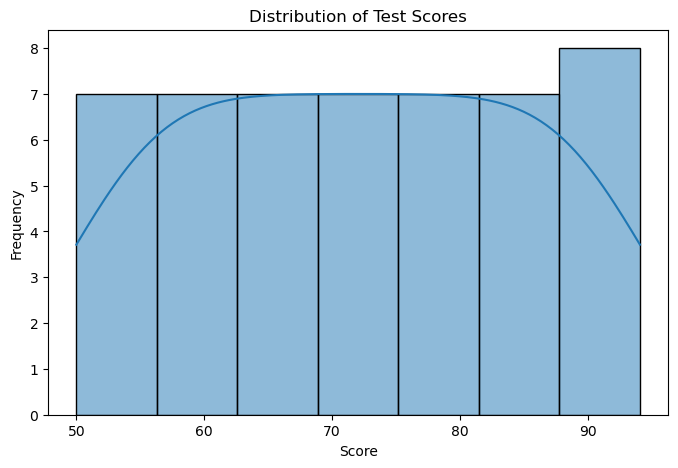

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["test_score"],kde=True)

plt.title("Distribution of Test Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")


plt.savefig(f"{GRAPH_PATH}\\test_score_distribution.png",dpi=300,bbox_inches="tight")

plt.show()

In [9]:
# dropping unneccercary coloumns


df = df.drop("student_id", axis=1)

df.head()

,gender,hours_studied,attendance_percent,assignments_completed,test_score
0,Female,6.3,61,6,50.9
1,Male,7.6,62,7,51.8
2,Female,8.9,63,8,52.7
3,Male,10.2,64,9,53.6
4,Female,11.5,65,10,54.5


In [10]:
# encode gender

le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])

df.head()

,gender,hours_studied,attendance_percent,assignments_completed,test_score
0,0,6.3,61,6,50.9
1,1,7.6,62,7,51.8
2,0,8.9,63,8,52.7
3,1,10.2,64,9,53.6
4,0,11.5,65,10,54.5


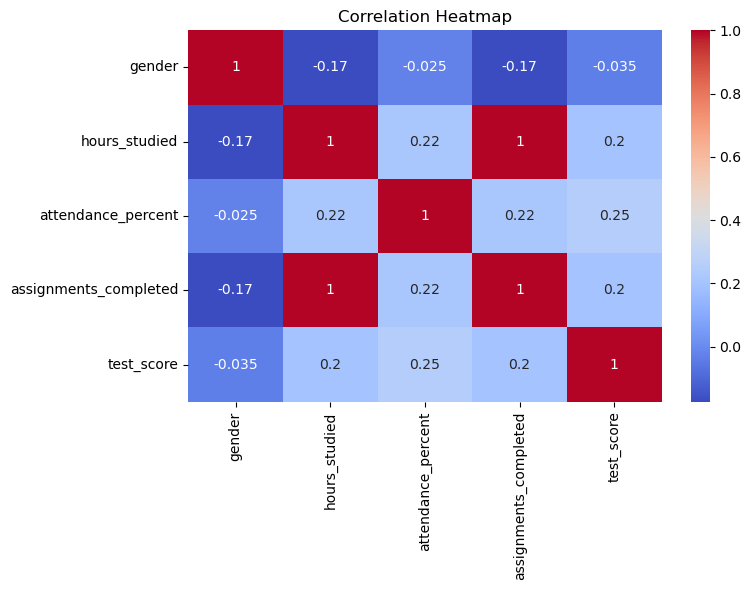

In [11]:
# lets find corelation between : columns 

corr_matrix = df.corr()

corr_matrix

plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix,annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(f"{GRAPH_PATH}\\correlation_heatmap.png",dpi=300,bbox_inches="tight")

plt.show()

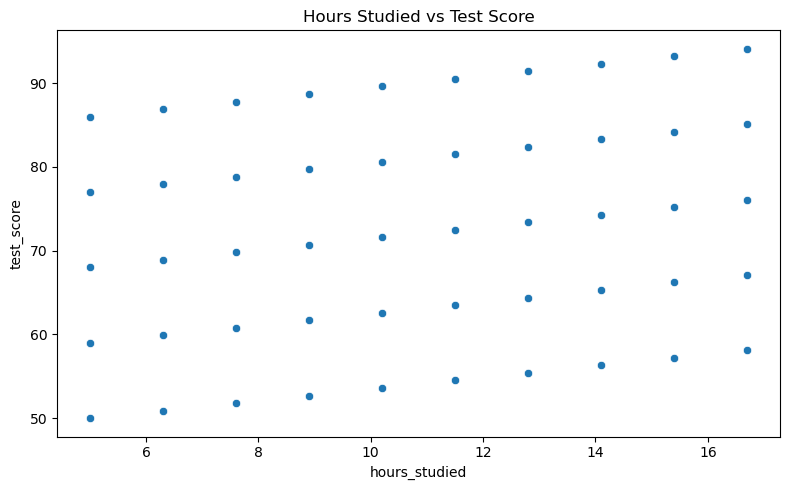

In [12]:
# hours studied vs test score

plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x="hours_studied",y="test_score")

plt.title("Hours Studied vs Test Score")

plt.tight_layout()

plt.savefig(f"{GRAPH_PATH}\\hours_vs_score.png",dpi=300,bbox_inches="tight")


plt.show()

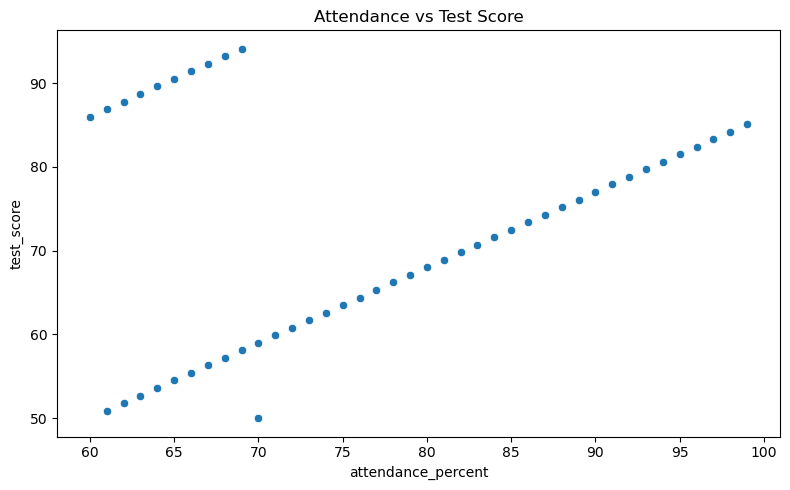

In [13]:
# Attendence vs Test Score

plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x="attendance_percent",y="test_score")

plt.title("Attendance vs Test Score")

plt.tight_layout()

plt.savefig(f"{GRAPH_PATH}\\attendance_vs_score.png",dpi=300,bbox_inches="tight")

plt.show()

In [14]:
# target and feature selection 

X = df.drop("test_score", axis=1)

y = df["test_score"]

In [15]:
# lets split the data 

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training XShape :", X_train.shape)

print("Testing y Shape :", X_test.shape)


Training XShape : (40, 4)
Testing y Shape : (10, 4)


In [16]:
# lr training 

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

y_pred

array([69.54094981, 62.17329864, 73.81140533, 67.94428701, 73.38827539,
       70.94507972, 76.06206811, 74.98493819, 75.73506812, 69.21394982])

In [17]:
# lets check acctual vs predicted 

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred})

comparison

,Actual,Predicted
13,62.6,69.540950
39,86.0,62.173299
30,77.9,73.811405
45,91.4,67.944287
17,66.2,73.388275
48,94.1,70.945080
26,74.3,76.062068
25,73.4,74.984938
32,79.7,75.735068
19,68.0,69.213950


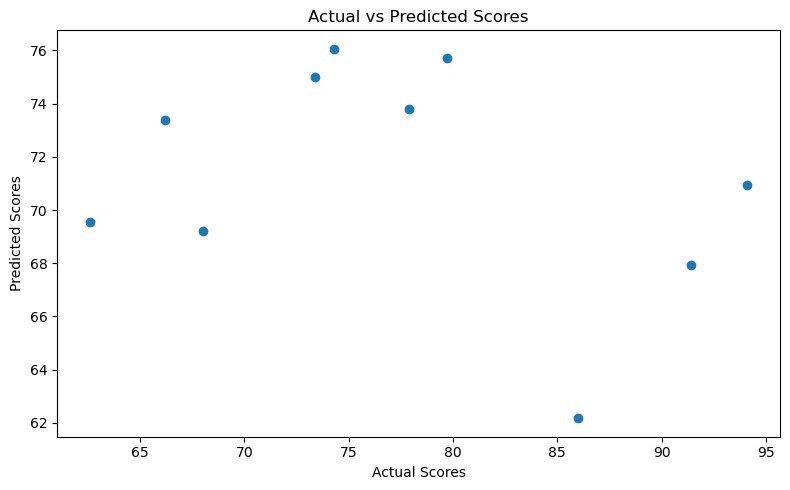

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")

plt.title("Actual vs Predicted Scores")

plt.tight_layout()

plt.savefig(f"{GRAPH_PATH}\\actual_vs_predicted.png",dpi=300,bbox_inches="tight")

plt.show()

In [19]:
#mae mse nd rmse (confusion matrix)


print("MAE :", mean_absolute_error(y_test, y_pred))

print("MSE :", mean_squared_error(y_test, y_pred))

print("RMSE :", np.sqrt( mean_squared_error(y_test, y_pred)))

print("R² Score :", r2_score(y_test,y_pred))

MAE : 9.718104249989837
MSE : 179.34084680426048
RMSE : 13.391820145307376
R² Score : -0.7707009984386279


In [20]:
# lets save our model 

import pickle

MODEL_PATH = r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\Students Success Predictor Model\Model\student_success_model.pkl"

with open(MODEL_PATH, "wb") as file:
    pickle.dump(lr, file)

print("Model Saved Successfully!")

Model Saved Successfully!


In [21]:
loaded_model = pickle.load(open(MODEL_PATH, "rb"))

print("Model Loaded Successfully")

Model Loaded Successfully


In [22]:
# final input 

gender = input("Enter Gender (Male/Female): ")

hours_studied = float(input("Enter Hours Studied: "))

attendance_percent = float(input("Enter Attendance Percentage: "))

assignments_completed = int(input("Enter Assignments Completed: "))

if gender.lower() == "male":
    gender = 1
else:
    gender = 0

sample_student = pd.DataFrame({
        "gender": [gender],
        "hours_studied": [hours_studied],
        "attendance_percent": [attendance_percent],
        "assignments_completed": [assignments_completed]
    })

prediction = loaded_model.predict(sample_student)

print(
    f"\nPredicted Test Score: {prediction[0]:.2f}")

Enter Gender (Male/Female):  Male
Enter Hours Studied:  12
Enter Attendance Percentage:  1
Enter Assignments Completed:  2



Predicted Test Score: 42.79
